<a href="https://colab.research.google.com/github/bellakinch/TruthSeeker-News-Analysis-/blob/main/TruthSeeker_Principal_Component_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Unnamed: 0  majority_target  \
0           0             True   
1           1             True   
2           2             True   
3           3             True   
4           4             True   

                                           statement  BinaryNumTarget  \
0  End of eviction moratorium means millions of A...              1.0   
1  End of eviction moratorium means millions of A...              1.0   
2  End of eviction moratorium means millions of A...              1.0   
3  End of eviction moratorium means millions of A...              1.0   
4  End of eviction moratorium means millions of A...              1.0   

                                               tweet  followers_count  \
0  @POTUS Biden Blunders - 6 Month Update\n\nInfl...           4262.0   
1  @S0SickRick @Stairmaster_ @6d6f636869 Not as m...           1393.0   
2  THE S

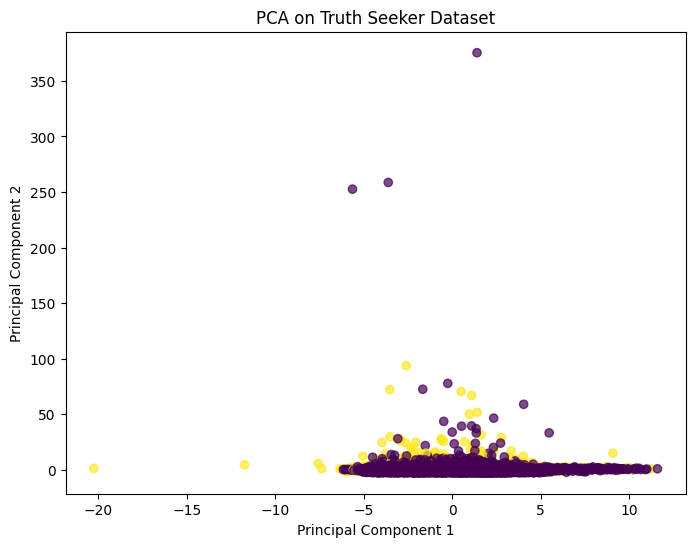

Original number of features: 58
Number of components kept: 40

Explained variance ratio per component:
  PC1: 0.0828 (8.28%)
  PC2: 0.0525 (5.25%)
  PC3: 0.0481 (4.81%)
  PC4: 0.0462 (4.62%)
  PC5: 0.0351 (3.51%)
  PC6: 0.0331 (3.31%)
  PC7: 0.0286 (2.86%)
  PC8: 0.0257 (2.57%)
  PC9: 0.0244 (2.44%)
  PC10: 0.0240 (2.40%)
  PC11: 0.0214 (2.14%)
  PC12: 0.0204 (2.04%)
  PC13: 0.0200 (2.00%)
  PC14: 0.0188 (1.88%)
  PC15: 0.0185 (1.85%)
  PC16: 0.0184 (1.84%)
  PC17: 0.0180 (1.80%)
  PC18: 0.0177 (1.77%)
  PC19: 0.0176 (1.76%)
  PC20: 0.0175 (1.75%)
  PC21: 0.0174 (1.74%)
  PC22: 0.0173 (1.73%)
  PC23: 0.0172 (1.72%)
  PC24: 0.0172 (1.72%)
  PC25: 0.0171 (1.71%)
  PC26: 0.0171 (1.71%)
  PC27: 0.0170 (1.70%)
  PC28: 0.0170 (1.70%)
  PC29: 0.0168 (1.68%)
  PC30: 0.0166 (1.66%)
  PC31: 0.0162 (1.62%)
  PC32: 0.0160 (1.60%)
  PC33: 0.0158 (1.58%)
  PC34: 0.0148 (1.48%)
  PC35: 0.0148 (1.48%)
  PC36: 0.0144 (1.44%)
  PC37: 0.0139 (1.39%)
  PC38: 0.0137 (1.37%)
  PC39: 0.0130 (1.30%)
  PC40: 0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1 --- Load and prepare the dataset ---
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Features_For_Traditional_ML_Techniques (1).csv')
print(df.head())
print(df.shape)

cols_to_drop = ['majority_target', 'statement',
'BinaryNumTarget', 'tweet', 'embeddings', 'following']
X_raw = df.drop(columns=cols_to_drop, errors='ignore')

# --- X_raw is the feature matrix used for PCS ----
# PCA is unsupervised, it must not see the target (BinaryNumTarget)
y = df['BinaryNumTarget'] # used to interpret PCA results later through viz and interpretation


# --- handle any nan values that might break the scaler ---
X_raw = X_raw.fillna(0)

# --- standardize the dataset ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 3 --- Apply PCA ---
pca = PCA(n_components=0.90)  # Retain 90% of variance
X_pca = pca.fit_transform(X_scaled)  # Apply PCA transformation

# 4 --- Visualize the PCA results ---
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Truth Seeker Dataset")
plt.show()

# 5 --- Analyze explained variance ---
print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of components kept: {pca.n_components_}")

print("\nExplained variance ratio per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

total_variance = np.sum(pca.explained_variance_ratio_)
print(f"\nTotal variance captured: {total_variance:.4f} ({total_variance*100:.2f}%)")

# 6 --- Examine PC1 feature contributions ---

pc1_loadings = pca.components_[0]

feature_contributions = pd.DataFrame({
    'Feature': X_raw.columns,
    'PC1 Loading': pc1_loadings
})

feature_contributions['Absolute Contribution'] = (
    feature_contributions['PC1 Loading'].abs()
)

feature_contributions = feature_contributions.sort_values(
    by='Absolute Contribution',
    ascending=False
)

print("\nTop 10 features contributing to PC1:")
print(feature_contributions.head(10))


# --- Create PCA DataFrame ---

pca_columns = [
    f'PC{i+1}' for i in range(X_pca.shape[1])
]

X_pca_df = pd.DataFrame(
    X_pca,
    columns=pca_columns
)

# --- Add target back AFTER PCA ---
X_pca_df['BinaryNumTarget'] = y.values

print("\nPCA DataFrame:")
print(X_pca_df.head())




PCA reduced the dataset from originally having 58 features to 40 principal components while retaining 90.48% of the total variance. This shows us that the PCA reduced the dimensionality of the dataset by 18 features while keeping most of the information represented by the original features from our dataset. PCA was effective at reducing the dimensionality without throwing away too much information.


---
**GRAPH  **

Purple = 0 = Fake

Yellow = 1 = Real

Most observations are concentrated near the center of the plot, with a bit of outliers from the PC2 values. Because all overlapping in classes, it means that PC1 and PC2 do not visually separate Fake vs. Real that well.
PC1/PC2 axis numbers = scores showing where each observation falls in PCA space.
            Color = the actual Fake/Real label.


---


Explained variance tells us how much information/ variation a principal component captures from the original data. PC1 captures 8.28% of the variation from the original 58 features.



---

The PC1 loadings show which original features contributed most strongly to the first principal component. The highest scored loading is Word count (0.4344). This means Word count contributes the most strongly to the pattern represented by PC1 (biggest overall pattern in my data). The second largest is short word req (0.4046). The strongest contributors are language and text features. This suggests that PC1 is capturing a pattern related to the linguistic structure and characteristics of the statements.

